# CrashLens — Targeted Hard-Class Experiments

This notebook continues the CrashLens CarDD damage detection experiments after the previous baseline study.

Goal: improve the difficult classes **dent, scratch, and crack** using targeted training-data augmentation/oversampling, then compare **SGD vs AdamW**, tune thresholds on validation, and evaluate once on the test set.

Protocol:
1. Build an augmented training dataset in Colab only.
2. Keep validation and test splits unchanged.
3. Train candidate models on the augmented training split.
4. Select the best model using validation only.
5. Tune confidence/IoU thresholds using validation only.
6. Evaluate once on the test set after all decisions are finalized.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics -q

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 75.9 MB/s eta 0:00:00


## 2. Imports, Paths, and Global Settings

In [2]:
from pathlib import Path
from datetime import datetime
from collections import defaultdict, Counter
import json
import shutil
import os
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Update only if your CarDD folder path differs.
DATASET_ROOT = Path('/content/drive/MyDrive/CarDD_release/CarDD_release/CarDD_COCO')

# Temporary Colab datasets
ORIGINAL_YOLO_DIR = Path('/content/cardd_yolo_original')
TARGET_YOLO_DIR = Path('/content/cardd_yolo_hardclass_augmented')

# New Drive folder. Previous experiment results remain untouched.
DRIVE_EXPERIMENTS_DIR = Path('/content/drive/MyDrive/CrashLens_ML_Targeted_HardClass_Experiments')
BASE_RUN_DIR = Path('/content/cardd_targeted_experiments')

BASE_RUN_DIR.mkdir(parents=True, exist_ok=True)
DRIVE_EXPERIMENTS_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = [
    'dent',
    'scratch',
    'crack',
    'glass shatter',
    'lamp broken',
    'tire flat'
]

HARD_CLASS_IDS = {0, 1, 2}  # dent, scratch, crack
HARD_CLASS_NAMES = [CLASS_NAMES[i] for i in sorted(HARD_CLASS_IDS)]

BASE_MODEL = 'yolov8s.pt'
SELECTED_IMGSZ = 640       # selected from previous validation study
SELECTED_EPOCHS = 150      # selected from previous validation study
BATCH_SIZE = 16
PATIENCE = 30

# Start conservatively: one augmented copy per hard-class image.
AUGMENTED_COPIES_PER_IMAGE = 1

print('Drive experiment folder:', DRIVE_EXPERIMENTS_DIR)
print('Hard classes:', HARD_CLASS_NAMES)

Drive experiment folder: /content/drive/MyDrive/CrashLens_ML_Targeted_HardClass_Experiments
Hard classes: ['dent', 'scratch', 'crack']


## 3. Convert Original CarDD COCO Annotations to YOLO Format

In [3]:
splits = {
    'train': 'train2017',
    'val': 'val2017',
    'test': 'test2017'
}

category_map = {
    1: 0,  # dent
    2: 1,  # scratch
    3: 2,  # crack
    4: 3,  # glass shatter
    5: 4,  # lamp broken
    6: 5   # tire flat
}

def convert_coco_to_yolo(dataset_root: Path, yolo_dir: Path):
    yolo_dir.mkdir(parents=True, exist_ok=True)

    for split, folder in splits.items():
        images_dir = yolo_dir / 'images' / split
        labels_dir = yolo_dir / 'labels' / split
        images_dir.mkdir(parents=True, exist_ok=True)
        labels_dir.mkdir(parents=True, exist_ok=True)

        ann_file = dataset_root / 'annotations' / f'instances_{folder}.json'
        with open(ann_file, 'r') as f:
            coco = json.load(f)

        images = {img['id']: img for img in coco['images']}

        annotations_by_image = defaultdict(list)
        for ann in coco['annotations']:
            annotations_by_image[ann['image_id']].append(ann)

        missing_images = []

        for image_id, img_info in images.items():
            file_name = img_info['file_name']
            img_w = img_info['width']
            img_h = img_info['height']

            src_img = dataset_root / folder / file_name
            dst_img = images_dir / file_name

            if src_img.exists():
                if not dst_img.exists():
                    shutil.copy(src_img, dst_img)
            else:
                missing_images.append(file_name)
                continue

            label_file = labels_dir / Path(file_name).with_suffix('.txt').name
            with open(label_file, 'w') as lf:
                for ann in annotations_by_image.get(image_id, []):
                    cat_id = ann['category_id']
                    if cat_id not in category_map:
                        continue

                    x, y, w, h = ann['bbox']
                    x_center = (x + w / 2) / img_w
                    y_center = (y + h / 2) / img_h
                    w_norm = w / img_w
                    h_norm = h / img_h
                    class_id = category_map[cat_id]

                    lf.write(
                        f'{class_id} {x_center:.6f} {y_center:.6f} '
                        f'{w_norm:.6f} {h_norm:.6f}\n'
                    )

        print(f'{split}: converted {len(images) - len(missing_images)} images')
        if missing_images:
            print(f'{split}: missing {len(missing_images)} images')

convert_coco_to_yolo(DATASET_ROOT, ORIGINAL_YOLO_DIR)

train: converted 2816 images
val: converted 810 images
test: converted 374 images


In [5]:
import shutil
from pathlib import Path

# Saving converted dataset to Drive
YOLO_DRIVE_data = Path('/content/drive/MyDrive/cardd_yolo_data')
shutil.copytree(ORIGINAL_YOLO_DIR, YOLO_DRIVE_data)
print("Saved successfully!")

Saved successfully!


## 4. Create Targeted Hard-Class Augmented Training Dataset

This creates extra augmented copies of **training images that contain at least one hard class**.

- Training split is augmented.
- Validation split is copied unchanged.
- Test split is copied unchanged.
- Bounding boxes stay valid because augmentations are photometric only.

In [6]:
def read_label_classes(label_path: Path):
    classes = set()
    if not label_path.exists():
        return classes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                classes.add(int(parts[0]))
    return classes

def photometric_hardclass_augment(image):
    # Photometric transforms only: labels remain unchanged.
    aug = image.copy()

    # Brightness/contrast
    alpha = random.uniform(0.90, 1.20)
    beta = random.randint(-12, 18)
    aug = cv2.convertScaleAbs(aug, alpha=alpha, beta=beta)

    # Mild sharpening
    if random.random() < 0.7:
        kernel = np.array([
            [0, -1, 0],
            [-1, 5, -1],
            [0, -1, 0]
        ])
        aug = cv2.filter2D(aug, -1, kernel)

    # Mild Gaussian noise
    if random.random() < 0.5:
        noise = np.random.normal(0, 5, aug.shape).astype(np.int16)
        aug = np.clip(aug.astype(np.int16) + noise, 0, 255).astype(np.uint8)

    return aug

def build_hardclass_augmented_dataset(original_yolo_dir: Path, target_yolo_dir: Path, hard_class_ids, copies_per_image: int = 1):
    if target_yolo_dir.exists():
        shutil.rmtree(target_yolo_dir)

    shutil.copytree(original_yolo_dir, target_yolo_dir)

    train_images_dir = target_yolo_dir / 'images' / 'train'
    train_labels_dir = target_yolo_dir / 'labels' / 'train'

    image_extensions = {'.jpg', '.jpeg', '.png'}
    train_images = [p for p in train_images_dir.iterdir() if p.suffix.lower() in image_extensions]

    selected_for_augmentation = []
    added_images = 0

    for image_path in train_images:
        label_path = train_labels_dir / image_path.with_suffix('.txt').name
        classes = read_label_classes(label_path)

        if classes & hard_class_ids:
            selected_for_augmentation.append(image_path)
            image = cv2.imread(str(image_path))
            if image is None:
                continue

            for copy_idx in range(1, copies_per_image + 1):
                aug_image = photometric_hardclass_augment(image)
                aug_stem = f'{image_path.stem}_hardaug{copy_idx}'
                aug_image_path = train_images_dir / f'{aug_stem}{image_path.suffix}'
                aug_label_path = train_labels_dir / f'{aug_stem}.txt'

                cv2.imwrite(str(aug_image_path), aug_image)
                shutil.copy(label_path, aug_label_path)
                added_images += 1

    return {
        'hard_classes': [CLASS_NAMES[i] for i in sorted(hard_class_ids)],
        'copies_per_image': copies_per_image,
        'selected_train_images': len(selected_for_augmentation),
        'added_augmented_images': added_images
    }

augmentation_summary = build_hardclass_augmented_dataset(
    original_yolo_dir=ORIGINAL_YOLO_DIR,
    target_yolo_dir=TARGET_YOLO_DIR,
    hard_class_ids=HARD_CLASS_IDS,
    copies_per_image=AUGMENTED_COPIES_PER_IMAGE
)

print(json.dumps(augmentation_summary, indent=4))

with open(DRIVE_EXPERIMENTS_DIR / 'hardclass_augmentation_summary.json', 'w') as f:
    json.dump(augmentation_summary, f, indent=4)

{
    "hard_classes": [
        "dent",
        "scratch",
        "crack"
    ],
    "copies_per_image": 1,
    "selected_train_images": 2184,
    "added_augmented_images": 2184
}


## 5. Create `data.yaml` Files

In [7]:
def write_data_yaml(yolo_dir: Path, yaml_path: Path):
    yaml_lines = [
        f'path: {yolo_dir}',
        'train: images/train',
        'val: images/val',
        'test: images/test',
        '',
        'nc: 6',
        '',
        'names:',
        '  0: dent',
        '  1: scratch',
        '  2: crack',
        '  3: glass shatter',
        '  4: lamp broken',
        '  5: tire flat'
    ]
    yaml_content = '\n'.join(yaml_lines) + '\n'
    with open(yaml_path, 'w') as f:
        f.write(yaml_content)
    print(f'Created: {yaml_path}')
    print(open(yaml_path).read())

original_data_yaml_path = ORIGINAL_YOLO_DIR / 'data.yaml'
target_data_yaml_path = TARGET_YOLO_DIR / 'data.yaml'

write_data_yaml(ORIGINAL_YOLO_DIR, original_data_yaml_path)
write_data_yaml(TARGET_YOLO_DIR, target_data_yaml_path)

Created: /content/cardd_yolo_original/data.yaml
path: /content/cardd_yolo_original
train: images/train
val: images/val
test: images/test

nc: 6

names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat

Created: /content/cardd_yolo_hardclass_augmented/data.yaml
path: /content/cardd_yolo_hardclass_augmented
train: images/train
val: images/val
test: images/test

nc: 6

names:
  0: dent
  1: scratch
  2: crack
  3: glass shatter
  4: lamp broken
  5: tire flat



## 6. Dataset Verification and Leakage Check

In [8]:
image_extensions = {'.jpg', '.jpeg', '.png'}

def verify_yolo_dataset(yolo_dir: Path, name: str):
    print(f'\nDataset: {name}')
    verification = {}

    for split in ['train', 'val', 'test']:
        images_dir = yolo_dir / 'images' / split
        labels_dir = yolo_dir / 'labels' / split

        image_files = [p for p in images_dir.iterdir() if p.suffix.lower() in image_extensions]
        label_files = list(labels_dir.glob('*.txt'))

        verification[split] = {'images': len(image_files), 'labels': len(label_files)}
        print(f'{split}: images={len(image_files)}, labels={len(label_files)}')

    train_files = {p.name for p in (yolo_dir / 'images/train').iterdir() if p.suffix.lower() in image_extensions}
    val_files = {p.name for p in (yolo_dir / 'images/val').iterdir() if p.suffix.lower() in image_extensions}
    test_files = {p.name for p in (yolo_dir / 'images/test').iterdir() if p.suffix.lower() in image_extensions}

    print('Train-Val overlap:', len(train_files & val_files))
    print('Train-Test overlap:', len(train_files & test_files))
    print('Val-Test overlap:', len(val_files & test_files))

    return verification

original_verification = verify_yolo_dataset(ORIGINAL_YOLO_DIR, 'original')
target_verification = verify_yolo_dataset(TARGET_YOLO_DIR, 'hard-class augmented')

with open(DRIVE_EXPERIMENTS_DIR / 'dataset_verification.json', 'w') as f:
    json.dump({'original': original_verification, 'hardclass_augmented': target_verification}, f, indent=4)


Dataset: original
train: images=2816, labels=2816
val: images=810, labels=810
test: images=374, labels=374
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0

Dataset: hard-class augmented
train: images=5000, labels=5000
val: images=810, labels=810
test: images=374, labels=374
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


In [9]:
def count_yolo_labels(labels_dir: Path, class_names):
    counts = Counter()
    for label_file in labels_dir.glob('*.txt'):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if parts:
                    class_id = int(parts[0])
                    counts[class_names[class_id]] += 1
    return counts

original_train_counts = count_yolo_labels(ORIGINAL_YOLO_DIR / 'labels/train', CLASS_NAMES)
target_train_counts = count_yolo_labels(TARGET_YOLO_DIR / 'labels/train', CLASS_NAMES)

class_count_df = pd.DataFrame({
    'class': CLASS_NAMES,
    'original_train_objects': [original_train_counts.get(c, 0) for c in CLASS_NAMES],
    'augmented_train_objects': [target_train_counts.get(c, 0) for c in CLASS_NAMES],
})
class_count_df['increase'] = class_count_df['augmented_train_objects'] - class_count_df['original_train_objects']

display(class_count_df)
class_count_df.to_csv(DRIVE_EXPERIMENTS_DIR / 'class_distribution_original_vs_augmented.csv', index=False)

,class,original_train_objects,augmented_train_objects,increase
0,dent,1806,3612,1806
1,scratch,2560,5120,2560
2,crack,651,1302,651
3,glass shatter,475,553,78
4,lamp broken,494,919,425
5,tire flat,225,274,49


## 7. Experiment Configuration

In [10]:
EXPERIMENTS = [
    {
        'phase': 'targeted_hardclass_aug_optimizer',
        'name': f'yolov8s_img{SELECTED_IMGSZ}_hardaug_sgd_ep{SELECTED_EPOCHS}',
        'dataset_variant': 'hardclass_augmented',
        'model': BASE_MODEL,
        'imgsz': SELECTED_IMGSZ,
        'epochs': SELECTED_EPOCHS,
        'batch': BATCH_SIZE,
        'patience': PATIENCE,
        'optimizer': 'SGD',
        'lr0': 0.01,
        'momentum': 0.937,
        'weight_decay': 0.0005
    },
    {
        'phase': 'targeted_hardclass_aug_optimizer',
        'name': f'yolov8s_img{SELECTED_IMGSZ}_hardaug_adamw_ep{SELECTED_EPOCHS}',
        'dataset_variant': 'hardclass_augmented',
        'model': BASE_MODEL,
        'imgsz': SELECTED_IMGSZ,
        'epochs': SELECTED_EPOCHS,
        'batch': BATCH_SIZE,
        'patience': PATIENCE,
        'optimizer': 'AdamW',
        'lr0': 0.001,
        'weight_decay': 0.01
    }
]

with open(DRIVE_EXPERIMENTS_DIR / 'experiments_config.json', 'w') as f:
    json.dump(EXPERIMENTS, f, indent=4)

print(json.dumps(EXPERIMENTS, indent=4))

[
    {
        "phase": "targeted_hardclass_aug_optimizer",
        "name": "yolov8s_img640_hardaug_sgd_ep150",
        "dataset_variant": "hardclass_augmented",
        "model": "yolov8s.pt",
        "imgsz": 640,
        "epochs": 150,
        "batch": 16,
        "patience": 30,
        "optimizer": "SGD",
        "lr0": 0.01,
        "momentum": 0.937,
        "weight_decay": 0.0005
    },
    {
        "phase": "targeted_hardclass_aug_optimizer",
        "name": "yolov8s_img640_hardaug_adamw_ep150",
        "dataset_variant": "hardclass_augmented",
        "model": "yolov8s.pt",
        "imgsz": 640,
        "epochs": 150,
        "batch": 16,
        "patience": 30,
        "optimizer": "AdamW",
        "lr0": 0.001,
        "weight_decay": 0.01
    }
]


## 8. Training and Validation Loop

In [11]:
from ultralytics import YOLO

def run_experiment(exp, data_yaml_path: Path):
    timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    run_name = f"{exp['name']}_{timestamp}"
    local_run = BASE_RUN_DIR / run_name
    drive_run = DRIVE_EXPERIMENTS_DIR / run_name
    local_run.mkdir(parents=True, exist_ok=True)

    with open(local_run / 'experiment_config.json', 'w') as f:
        json.dump(exp, f, indent=4)

    print(f"\nStarting experiment: {run_name}")

    model = YOLO(exp['model'])

    train_kwargs = {
        'data': str(data_yaml_path),
        'imgsz': exp['imgsz'],
        'epochs': exp['epochs'],
        'batch': exp['batch'],
        'patience': exp['patience'],
        'project': str(local_run / 'training'),
        'name': 'train',
        'exist_ok': True,
        'seed': SEED,
        'deterministic': True,
        'optimizer': exp['optimizer'],
        'lr0': exp['lr0'],
        'weight_decay': exp['weight_decay']
    }

    if 'momentum' in exp:
        train_kwargs['momentum'] = exp['momentum']

    model.train(**train_kwargs)

    best_weights = local_run / 'training' / 'train' / 'weights' / 'best.pt'
    if not best_weights.exists():
        raise FileNotFoundError(f'Best weights not found: {best_weights}')

    model = YOLO(str(best_weights))

    val_result = model.val(
        data=str(data_yaml_path),
        split='val',
        imgsz=exp['imgsz'],
        project=str(local_run / 'validation'),
        name='val',
        exist_ok=True
    )

    summary = {
        'run_name': run_name,
        'source': 'targeted_hardclass_experiment',
        'weights_path': str(best_weights),
        **exp,
        'val_mAP50': float(val_result.box.map50),
        'val_mAP50_95': float(val_result.box.map),
        'val_precision': float(val_result.box.mp),
        'val_recall': float(val_result.box.mr)
    }

    for class_name, value in zip(CLASS_NAMES, val_result.box.maps):
        summary[f'val_map50_95_{class_name}'] = float(value)

    with open(local_run / 'summary.json', 'w') as f:
        json.dump(summary, f, indent=4)

    if drive_run.exists():
        shutil.rmtree(drive_run)

    shutil.copytree(local_run, drive_run)
    summary['weights_path'] = str(drive_run / 'training' / 'train' / 'weights' / 'best.pt')

    print(f'Saved to Drive: {drive_run}')
    return summary

all_results = []

for exp in EXPERIMENTS:
    summary = run_experiment(exp, target_data_yaml_path)
    all_results.append(summary)

new_results_df = pd.DataFrame(all_results).sort_values(
    by='val_mAP50_95',
    ascending=False
).reset_index(drop=True)

new_results_df.to_csv(DRIVE_EXPERIMENTS_DIR / 'targeted_experiment_comparison.csv', index=False)
display(new_results_df)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

Starting experiment: yolov8s_img640_hardaug_sgd_ep150_20260430_235704
Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cardd_yolo_hardclass_augmented/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=150, erasing=0.4, exist_ok=True, fliplr=0.5, fli

,run_name,source,weights_path,phase,name,dataset_variant,model,imgsz,epochs,batch,...,val_mAP50,val_mAP50_95,val_precision,val_recall,val_map50_95_dent,val_map50_95_scratch,val_map50_95_crack,val_map50_95_glass shatter,val_map50_95_lamp broken,val_map50_95_tire flat
0,yolov8s_img640_hardaug_sgd_ep150_20260430_235704,targeted_hardclass_experiment,/content/drive/MyDrive/CrashLens_ML_Targeted_H...,targeted_hardclass_aug_optimizer,yolov8s_img640_hardaug_sgd_ep150,hardclass_augmented,yolov8s.pt,640,150,16,...,0.717144,0.564630,0.784229,0.695523,0.290293,0.280069,0.253185,0.943665,0.756108,0.864459
1,yolov8s_img640_hardaug_adamw_ep150_20260501_01...,targeted_hardclass_experiment,/content/drive/MyDrive/CrashLens_ML_Targeted_H...,targeted_hardclass_aug_optimizer,yolov8s_img640_hardaug_adamw_ep150,hardclass_augmented,yolov8s.pt,640,150,16,...,0.719901,0.562617,0.799483,0.681066,0.300106,0.295850,0.236786,0.924247,0.742285,0.876426


## 9. Optional: Add Previous Best Baseline as a Reference Row

In [12]:
PREVIOUS_EXPERIMENTS_DIR = Path('/content/drive/MyDrive/CrashLens_ML_Experiments')
PREVIOUS_COMPARISON_CSV = PREVIOUS_EXPERIMENTS_DIR / 'experiment_comparison.csv'

reference_rows = []

if PREVIOUS_COMPARISON_CSV.exists():
    prev_df = pd.read_csv(PREVIOUS_COMPARISON_CSV)
    if 'val_mAP50_95' in prev_df.columns and len(prev_df) > 0:
        prev_best = prev_df.sort_values(by='val_mAP50_95', ascending=False).iloc[0].to_dict()
        prev_best['source'] = 'previous_original_reference'

        prev_run_name = prev_best.get('run_name', '')
        prev_weights = PREVIOUS_EXPERIMENTS_DIR / str(prev_run_name) / 'training' / 'train' / 'weights' / 'best.pt'
        prev_best['weights_path'] = str(prev_weights) if prev_weights.exists() else ''

        reference_rows.append(prev_best)
        print('Loaded previous best reference:', prev_run_name)
    else:
        print('Previous comparison file found, but val_mAP50_95 column is missing or file is empty.')
else:
    print('Previous comparison CSV not found. Skipping reference row.')

combined_results_df = pd.concat(
    [pd.DataFrame(reference_rows), new_results_df],
    ignore_index=True,
    sort=False
)

combined_results_df = combined_results_df.sort_values(
    by='val_mAP50_95',
    ascending=False
).reset_index(drop=True)

combined_results_df.to_csv(DRIVE_EXPERIMENTS_DIR / 'combined_comparison_with_previous_reference.csv', index=False)
display(combined_results_df)

Loaded previous best reference: yolov8s_img640_ep150_20260429_205427


,run_name,phase,model,imgsz,epochs,batch,patience,augmentation,multi_scale,val_mAP50,...,val_map50_95_glass shatter,val_map50_95_lamp broken,val_map50_95_tire flat,source,name,dataset_variant,optimizer,lr0,momentum,weight_decay
0,yolov8s_img640_hardaug_sgd_ep150_20260430_235704,targeted_hardclass_aug_optimizer,yolov8s.pt,640,150,16,30,NaN,NaN,0.717144,...,0.943665,0.756108,0.864459,targeted_hardclass_experiment,yolov8s_img640_hardaug_sgd_ep150,hardclass_augmented,SGD,0.010,0.937,0.0005
1,yolov8s_img640_ep150_20260429_205427,phase_2_extendedD_epochs,yolov8s.pt,640,150,16,25,False,False,0.708914,...,0.938237,0.764342,0.904706,previous_original_reference,NaN,NaN,NaN,NaN,NaN,NaN
2,yolov8s_img640_hardaug_adamw_ep150_20260501_01...,targeted_hardclass_aug_optimizer,yolov8s.pt,640,150,16,30,NaN,NaN,0.719901,...,0.924247,0.742285,0.876426,targeted_hardclass_experiment,yolov8s_img640_hardaug_adamw_ep150,hardclass_augmented,AdamW,0.001,NaN,0.0100


## 10. Select Best Model Based on Validation

In [13]:
best_experiment = combined_results_df.iloc[0]
best_run_name = best_experiment['run_name']
selected_weights = Path(best_experiment['weights_path'])
selected_imgsz = int(best_experiment['imgsz'])

if not selected_weights.exists():
    raise FileNotFoundError(
        f'Selected weights do not exist: {selected_weights}. '
        'If the previous reference was selected but weights are missing, select one of the new runs manually.'
    )

print('Selected best validation model:')
display(best_experiment)
print('Selected weights:', selected_weights)

Selected best validation model:


,0
run_name,yolov8s_img640_hardaug_sgd_ep150_20260430_235704
phase,targeted_hardclass_aug_optimizer
model,yolov8s.pt
imgsz,640
epochs,150
batch,16
patience,30
augmentation,NaN
multi_scale,NaN
val_mAP50,0.717144


Selected weights: /content/drive/MyDrive/CrashLens_ML_Targeted_HardClass_Experiments/yolov8s_img640_hardaug_sgd_ep150_20260430_235704/training/train/weights/best.pt


## 11. Per-Class Validation Metrics for Selected Model

In [14]:
per_class_cols = [col for col in combined_results_df.columns if str(col).startswith('val_map50_95_')]

per_class_df = best_experiment[per_class_cols].reset_index()
per_class_df.columns = ['metric', 'val_mAP50_95']
per_class_df['class'] = per_class_df['metric'].str.replace('val_map50_95_', '', regex=False)
per_class_df = per_class_df[['class', 'val_mAP50_95']]

display(per_class_df)
per_class_df.to_csv(DRIVE_EXPERIMENTS_DIR / 'selected_model_per_class_validation_metrics.csv', index=False)

,class,val_mAP50_95
0,dent,0.290293
1,scratch,0.280069
2,crack,0.253185
3,glass shatter,0.943665
4,lamp broken,0.756108
5,tire flat,0.864459


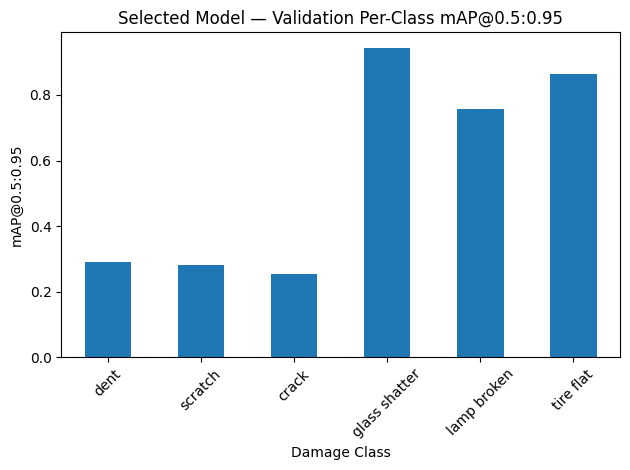

In [15]:
per_class_df.set_index('class')['val_mAP50_95'].plot(kind='bar')
plt.title('Selected Model — Validation Per-Class mAP@0.5:0.95')
plt.ylabel('mAP@0.5:0.95')
plt.xlabel('Damage Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(DRIVE_EXPERIMENTS_DIR / 'selected_model_per_class_validation_map.png', dpi=200)
plt.show()

## 12. Threshold and IoU Tuning on Validation

In [16]:
THRESHOLD_GRID = [
    {'conf': 0.15, 'iou': 0.50},
    {'conf': 0.15, 'iou': 0.70},
    {'conf': 0.25, 'iou': 0.50},
    {'conf': 0.25, 'iou': 0.70},
    {'conf': 0.35, 'iou': 0.50},
    {'conf': 0.35, 'iou': 0.70},
]

threshold_dir = DRIVE_EXPERIMENTS_DIR / 'threshold_tuning'
threshold_dir.mkdir(parents=True, exist_ok=True)

threshold_results = []
best_model = YOLO(str(selected_weights))

for item in THRESHOLD_GRID:
    conf = item['conf']
    iou = item['iou']

    val_threshold_result = best_model.val(
        data=str(target_data_yaml_path),
        split='val',
        imgsz=selected_imgsz,
        conf=conf,
        iou=iou,
        project=str(threshold_dir),
        name=f"conf{conf}_iou{iou}",
        exist_ok=True
    )

    precision = float(val_threshold_result.box.mp)
    recall = float(val_threshold_result.box.mr)
    f1 = 0.0 if precision + recall == 0 else 2 * precision * recall / (precision + recall)

    threshold_results.append({
        'selected_run_name': best_run_name,
        'conf': conf,
        'iou': iou,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'mAP50': float(val_threshold_result.box.map50),
        'mAP50_95': float(val_threshold_result.box.map)
    })

threshold_df = pd.DataFrame(threshold_results).sort_values(by='f1', ascending=False).reset_index(drop=True)
threshold_df.to_csv(threshold_dir / 'threshold_comparison.csv', index=False)
display(threshold_df)

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3848.9±73.5 MB/s, size: 730.5 KB)
val: Scanning /content/cardd_yolo_hardclass_augmented/labels/val.cache... 810 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 810/810 308.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 51/51 10.8it/s 4.7s
                   all        810       1744      0.794      0.697      0.669      0.538
                  dent        352        501      0.719      0.515      0.479      0.255
               scratch        431        728      0.637      0.503      0.425      0.244
                 crack        122        177      0.623      0.492      0.423      0.228
         glass shatter        134        135      0.986      0.978      0.985      0.936
           

,selected_run_name,conf,iou,precision,recall,f1,mAP50,mAP50_95
0,yolov8s_img640_hardaug_sgd_ep150_20260430_235704,0.35,0.5,0.801490,0.692638,0.743099,0.649430,0.524580
1,yolov8s_img640_hardaug_sgd_ep150_20260430_235704,0.15,0.5,0.794447,0.697336,0.742731,0.669341,0.538457
2,yolov8s_img640_hardaug_sgd_ep150_20260430_235704,0.25,0.5,0.795074,0.696453,0.742503,0.658094,0.530169
3,yolov8s_img640_hardaug_sgd_ep150_20260430_235704,0.25,0.7,0.788373,0.694207,0.738299,0.658741,0.531608
4,yolov8s_img640_hardaug_sgd_ep150_20260430_235704,0.35,0.7,0.786373,0.694979,0.737857,0.649379,0.525261
5,yolov8s_img640_hardaug_sgd_ep150_20260430_235704,0.15,0.7,0.784229,0.695523,0.737217,0.670580,0.540246


## 13. Formal Test Evaluation

In [17]:
best_threshold = threshold_df.iloc[0]

test_dir = DRIVE_EXPERIMENTS_DIR / 'final_test'
test_dir.mkdir(parents=True, exist_ok=True)

test_result = best_model.val(
    data=str(target_data_yaml_path),
    split='test',
    imgsz=selected_imgsz,
    conf=float(best_threshold['conf']),
    iou=float(best_threshold['iou']),
    project=str(test_dir),
    name='test',
    exist_ok=True
)

test_summary = {
    'selected_model': best_run_name,
    'selected_weights': str(selected_weights),
    'selected_imgsz': selected_imgsz,
    'selected_conf': float(best_threshold['conf']),
    'selected_iou': float(best_threshold['iou']),
    'test_mAP50': float(test_result.box.map50),
    'test_mAP50_95': float(test_result.box.map),
    'test_precision': float(test_result.box.mp),
    'test_recall': float(test_result.box.mr)
}

for class_name, value in zip(CLASS_NAMES, test_result.box.maps):
    test_summary[f'test_map50_95_{class_name}'] = float(value)

with open(test_dir / 'test_summary.json', 'w') as f:
    json.dump(test_summary, f, indent=4)

test_summary

Ultralytics 8.4.45 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (NVIDIA A100-SXM4-80GB, 81153MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2604.7±1188.6 MB/s, size: 714.7 KB)
val: Scanning /content/cardd_yolo_hardclass_augmented/labels/test... 374 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 374/374 1.5Kit/s 0.2s
val: New cache created: /content/cardd_yolo_hardclass_augmented/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 24/24 8.1it/s 3.0s
                   all        374        785      0.822      0.648      0.626      0.501
                  dent        157        236      0.697      0.507      0.469      0.277
               scratch        183        307      0.711      0.469      0.441      0.228
                 crack         48         70      0.679      0.386      0.329       0.19
         glass shatter         71         71      0.958      0.956      0.953       0.89
           lamp b

{'selected_model': 'yolov8s_img640_hardaug_sgd_ep150_20260430_235704',
 'selected_weights': '/content/drive/MyDrive/CrashLens_ML_Targeted_HardClass_Experiments/yolov8s_img640_hardaug_sgd_ep150_20260430_235704/training/train/weights/best.pt',
 'selected_imgsz': 640,
 'selected_conf': 0.35,
 'selected_iou': 0.5,
 'test_mAP50': 0.6258931863115483,
 'test_mAP50_95': 0.5007145310859994,
 'test_precision': 0.8215610934623019,
 'test_recall': 0.647688625212208,
 'test_map50_95_dent': 0.276582914931096,
 'test_map50_95_scratch': 0.22795857990165147,
 'test_map50_95_crack': 0.18989602700500335,
 'test_map50_95_glass shatter': 0.8896868826607692,
 'test_map50_95_lamp broken': 0.6052068868874951,
 'test_map50_95_tire flat': 0.8149558951299818}

## 14. Prediction Samples for Visual Inspection

In [18]:
prediction_dir = DRIVE_EXPERIMENTS_DIR / 'predictions'

best_model.predict(
    source=str(TARGET_YOLO_DIR / 'images/test'),
    imgsz=selected_imgsz,
    conf=float(best_threshold['conf']),
    iou=float(best_threshold['iou']),
    save=True,
    project=str(prediction_dir),
    name='test_predictions',
    exist_ok=True
)

print('Predictions saved to:', prediction_dir)


image 1/374 /content/cardd_yolo_hardclass_augmented/images/test/000012.jpg: 448x640 1 tire flat, 74.5ms
image 2/374 /content/cardd_yolo_hardclass_augmented/images/test/000015.jpg: 448x640 1 scratch, 7.5ms
image 3/374 /content/cardd_yolo_hardclass_augmented/images/test/000023.jpg: 448x640 (no detections), 7.4ms
image 4/374 /content/cardd_yolo_hardclass_augmented/images/test/000033.jpg: 640x448 1 dent, 71.8ms
image 5/374 /content/cardd_yolo_hardclass_augmented/images/test/000040.jpg: 448x640 (no detections), 8.0ms
image 6/374 /content/cardd_yolo_hardclass_augmented/images/test/000042.jpg: 448x640 2 dents, 2 scratchs, 1 glass shatter, 7.6ms
image 7/374 /content/cardd_yolo_hardclass_augmented/images/test/000044.jpg: 448x640 1 dent, 1 scratch, 2 cracks, 7.5ms
image 8/374 /content/cardd_yolo_hardclass_augmented/images/test/000057.jpg: 448x640 1 tire flat, 7.2ms
image 9/374 /content/cardd_yolo_hardclass_augmented/images/test/000082.jpg: 448x640 1 dent, 2 scratchs, 7.3ms
image 10/374 /content

## 15. Final Output Structure

Expected Drive structure:

```text
CrashLens_ML_Targeted_HardClass_Experiments/
├── hardclass_augmentation_summary.json
├── dataset_verification.json
├── class_distribution_original_vs_augmented.csv
├── experiments_config.json
├── targeted_experiment_comparison.csv
├── combined_comparison_with_previous_reference.csv
├── selected_model_per_class_validation_metrics.csv
├── selected_model_per_class_validation_map.png
├── threshold_tuning/
│   └── threshold_comparison.csv
├── final_test/
│   └── test/
└── <each training run>/
    ├── experiment_config.json
    ├── summary.json
    ├── training/
    └── validation/
```